# NB99 – Daten-Provenienz & Werdegang
### CAS Information Engineering – Scripting Project (Dev/Helper)
**Gruppe:** SC26_Gruppe_2 | **Datum:** März–Mai 2026

---
Visualisiert die Daten-Pipeline anhand von `dataindex.csv`.  
**Manuell ausführen** — nicht Teil von `run_all.sh`.  
Voraussetzung: NB01–NB02 wurden bereits ausgeführt (dataindex.csv vorhanden).

---
[↑ Projektübersicht](00_Project_Overview.ipynb)


---
## Setup


In [1]:
import os
import warnings
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates  as mdates
from   matplotlib.sankey import Sankey
from   datetime import datetime
warnings.filterwarnings('ignore')

import json as _json
with open('config.json') as _cf: CFG = _json.load(_cf)
DATAINDEX  = 'dataindex.csv'
CHARTS_DIR = os.path.join('output', 'charts', 'realistisch')  # NB99: kein Szenario-Param nötig
os.makedirs(CHARTS_DIR, exist_ok=True)
_viz       = CFG.get('visualisierung', {}).get('farben', {})
BG_DARK    = _viz.get('bg_dark',    '#0d1117')
BG_PANEL   = _viz.get('bg_panel',   '#141414')

# ── Dunkles Theme (konsistent mit NB3) ───────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : BG_DARK,
    'axes.facecolor'   : BG_PANEL,
    'axes.edgecolor'   : '#333333',
    'axes.labelcolor'  : '#aaaaaa',
    'xtick.color'      : '#bbbbbb',
    'ytick.color'      : '#bbbbbb',
    'text.color'       : 'white',
    'grid.color'       : '#2a2a2a',
    'grid.linewidth'   : 0.6,
})

STATUS_COLORS = {
    'active'    : '#66BB6A',  # grün
    'superseded': '#FFA726',  # orange
    'error'     : '#EF5350',  # rot
    'partial'   : '#42A5F5',  # blau
}
TYPE_COLORS = {
    'raw'         : '#1565C0',
    'processed'   : '#388E3C',
    'intermediate': '#FF6F00',
    'raw/sim'     : '#546E7A',
    'intermediate/sim': '#78909C',
}
TYPE_LABELS = {
    'raw'         : 'Rohdaten (raw/)',
    'processed'   : 'Bereinigt (processed/)',
    'intermediate': 'Zwischenergebnisse (intermediate/)',
    'raw/sim'     : 'Simuliert (sim/raw/)',
    'intermediate/sim': 'Simuliert (sim/intermediate/)',
}


**Setup.** Einheitliches dunkles Theme für alle Charts. `STATUS_COLORS` und `TYPE_COLORS`
kodieren den Zustand und die Verarbeitungsstufe jedes Eintrags konsistent über alle Visualisierungen.


---
## Daten laden und vorbereiten


In [2]:
# ── dataindex.csv laden ──────────────────────────────────────────────────────
if not os.path.exists(DATAINDEX):
    raise FileNotFoundError(
        f'dataindex.csv nicht gefunden. NB1 und NB2 müssen zuerst ausgeführt werden.')

df = pd.read_csv(DATAINDEX)
df['timestamp']      = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
df['superseded_at']  = pd.to_datetime(df['superseded_at'], utc=True, errors='coerce')
df['size_kb']        = pd.to_numeric(df['size_kb'], errors='coerce')
df['rows']           = pd.to_numeric(df['rows'],    errors='coerce')

# Kurzname für Anzeige (ohne Extension)
df['label'] = df['filename'].str.replace(r'\.(csv|gpkg|json|xlsx)$', '', regex=True)

# Jüngster aktiver Eintrag pro Datei
df_active = df[df['status']=='active'].sort_values('timestamp')

print(f'Einträge gesamt   : {len(df)}')
print(f'Aktive Datensätze : {len(df_active)}')
print(f'Fehler            : {(df["status"]=="error").sum()}')
print(f'Superseded        : {(df["status"]=="superseded").sum()}')
print(f'\nZeitraum: {df["timestamp"].min().strftime("%Y-%m-%d %H:%M")} → '
      f'{df["timestamp"].max().strftime("%Y-%m-%d %H:%M")} UTC')
print()
print('Aktive Datensätze:')
for _, row in df_active.iterrows():
    size = f'{row["size_kb"]/1024:.1f} MB' if row['size_kb'] > 1024 else f'{row["size_kb"]:.0f} KB'
    rows_str = f'{int(row["rows"]):,} Zeilen' if pd.notna(row['rows']) else '—'
    print(f'  {row["filename"]:<35} [{row["data_type"]:<13}]  {size:>10}  {rows_str}')


Einträge gesamt   : 34
Aktive Datensätze : 8
Fehler            : 0
Superseded        : 26

Zeitraum: 2026-03-30 17:52 → 2026-03-31 19:17 UTC

Aktive Datensätze:
  spread_zeitreihe.csv                [intermediate ]        3 KB  40 Zeilen
  ch_import_export_analyse.csv        [intermediate ]      1.4 MB  28,432 Zeilen
  ch_spot_prices_clean.csv            [processed/sim]      nan KB  17,544 Zeilen
  ch_spot_prices_raw.csv              [raw/sim      ]      478 KB  17,544 Zeilen
  ch_netzlast_raw.csv                 [raw/sim      ]      495 KB  17,544 Zeilen
  wirtschaftlichkeit.csv              [intermediate ]        0 KB  4 Zeilen
  netzentlastung_szenarien.csv        [intermediate/realistisch]        0 KB  4 Zeilen
  bfs_gemeinden.csv                   [intermediate ]        0 KB  26 Zeilen


In [3]:
# ── Verifikation: dataindex.csv ─────────────────────────────────────────────
print(f'Einträge: {len(df)}')
print(f'Status  : {df["status"].value_counts().to_dict()}')
print(f'Typen   : {df["data_type"].value_counts().to_dict()}')
df[['filename','data_type','rows','size_kb','status']].head(5)


Einträge: 34
Status  : {'superseded': 26, 'active': 8}
Typen   : {'intermediate': 19, 'intermediate/realistisch': 7, 'raw': 2, 'raw/sim': 2, 'intermediate/sim': 2, 'processed': 1, 'processed/sim': 1}


,filename,data_type,rows,size_kb,status
0,ch_spot_prices_raw.csv,raw,28437,925.5,superseded
1,ch_netzlast_raw.csv,raw,28429,940.7,superseded
2,ch_spot_prices_clean.csv,processed,28463,1171.5,superseded
3,wirtschaftlichkeit.csv,intermediate,4,0.5,superseded
4,netzentlastung_szenarien.csv,intermediate/realistisch,4,0.4,superseded


**Datenüberblick.** Der dataindex liest sich wie ein Logbuch: jeder Eintrag ist
eine Zeile mit Zeitstempel, Status und Metadaten. Aktive Einträge sind der aktuelle Stand,
superseded Einträge zeigen die Versionsgeschichte.


---
## Chart A: Download-Zeitlinie


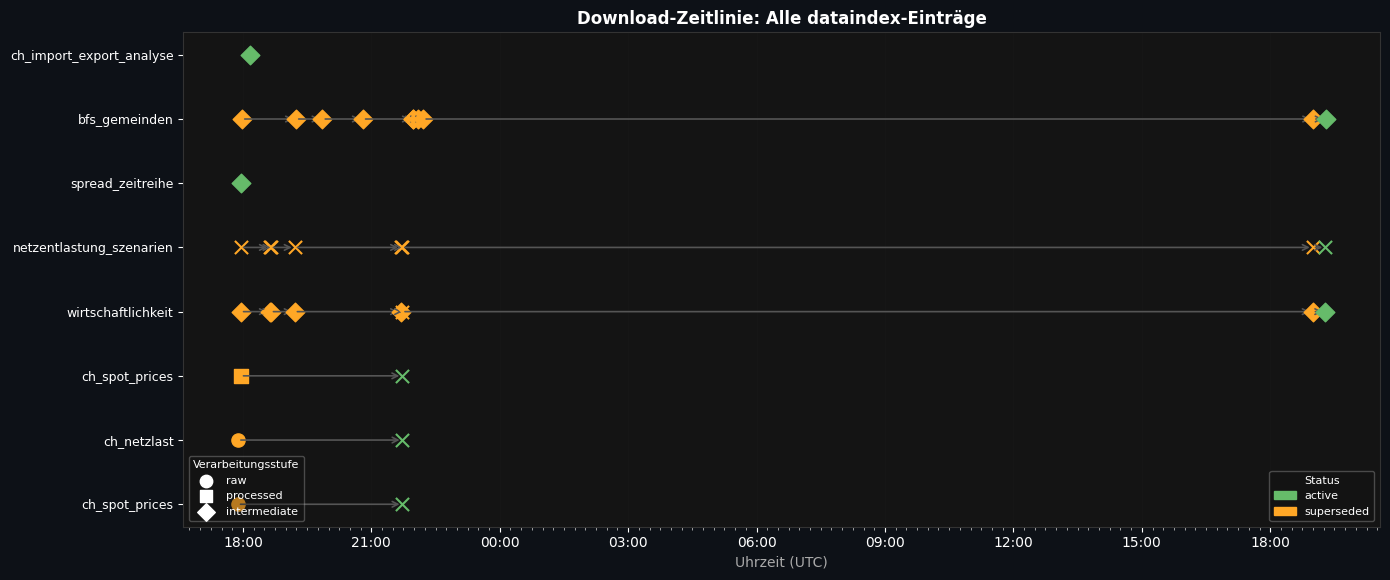

Chart A gespeichert: output\charts\realistisch\nb99_prov_zeitlinie.png


In [4]:
# ── Chart A: Zeitlinie aller Einträge ────────────────────────────────────────
# Jeder Eintrag als Punkt auf einem Zeitstrahl, gruppiert nach Datei
# Farbe = Status, Form = data_type

files_ordered = (df.sort_values('timestamp')
                   .groupby('filename')['timestamp'].min()
                   .sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(14, max(5, len(files_ordered)*0.55 + 1.5)))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#141414')

y_pos = {fname: i for i, fname in enumerate(files_ordered)}

for _, row in df.iterrows():
    y = y_pos[row['filename']]
    col = STATUS_COLORS.get(row['status'], '#888')
    marker = {'raw':'o','processed':'s','intermediate':'D'}.get(row['data_type'],'x')
    ax.scatter(row['timestamp'], y, color=col, marker=marker, s=90, zorder=3)
    # Pfeil von superseded → nachfolger
    if row['status'] == 'superseded' and pd.notna(row['superseded_at']):
        ax.annotate('', xy=(row['superseded_at'], y), xytext=(row['timestamp'], y),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.2))

# Fehler-X gross
for _, row in df[df['status']=='error'].iterrows():
    ax.scatter(row['timestamp'], y_pos[row['filename']],
               color='#EF5350', marker='x', s=160, linewidths=2.5, zorder=4)

ax.set_yticks(range(len(files_ordered)))
ax.set_yticklabels([f.replace('_raw','').replace('_clean','').replace('.csv','').replace('.gpkg','')
                    for f in files_ordered], fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0,15,30,45]))
ax.set_xlabel('Uhrzeit (UTC)', color='#aaa')
ax.set_title('Download-Zeitlinie: Alle dataindex-Einträge', color='white', fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.15)

# Legende Status
status_handles = [mpatches.Patch(color=c, label=s) for s,c in STATUS_COLORS.items() if s in df['status'].values]
# Legende Typ
type_handles = [plt.scatter([],[],color='white',marker=m,s=80,label=t)
                for t,m in [('raw','o'),('processed','s'),('intermediate','D')]]
leg1 = ax.legend(handles=status_handles, title='Status', loc='lower right',
                 fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white',
                 title_fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=type_handles, title='Verarbeitungsstufe', loc='lower left',
          fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white', title_fontsize=8)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'nb99_prov_zeitlinie.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Chart A gespeichert: {p}')


**Chart A — Download-Zeitlinie.** Jeder Punkt ist ein dataindex-Eintrag. Die Pfeile
zwischen orangefarbenen (superseded) und grünen (active) Punkten zeigen Re-Downloads —
entweder nach Fehlern (rotes X → grüner Kreis) oder nach bewussten Aktualisierungen.
Die Form kodiert die Verarbeitungsstufe (Kreis = raw, Quadrat = processed, Diamant = intermediate).


---
## Chart B: Dateigrössenvergleich


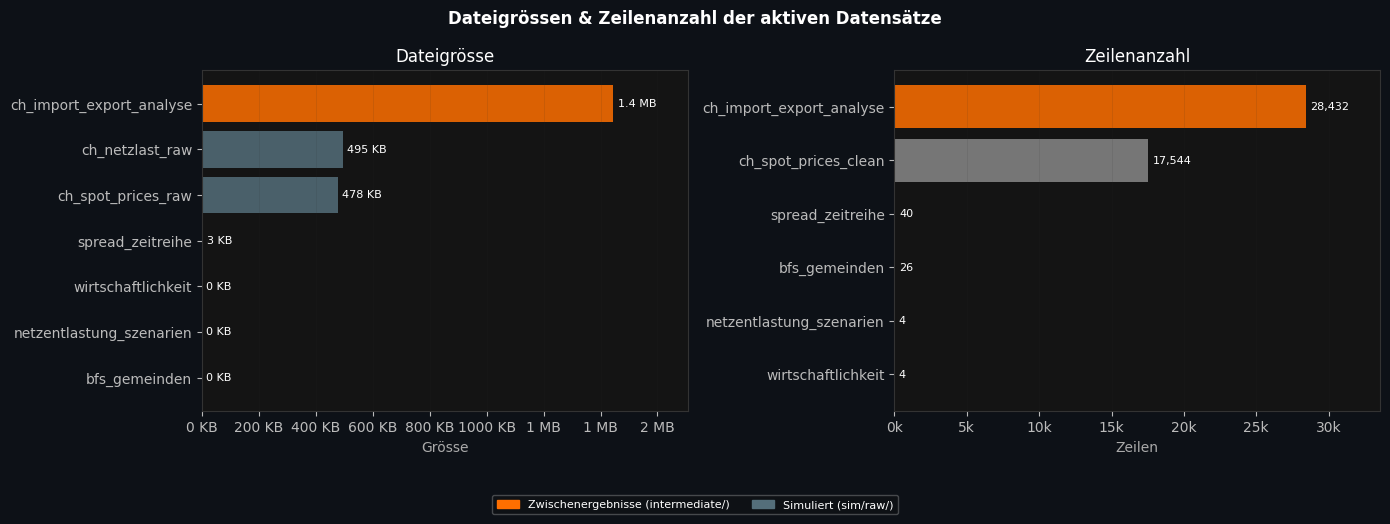

Chart B gespeichert: output\charts\realistisch\nb99_prov_dateigroessen.png


In [5]:
# ── Chart B: Grössenvergleich aktiver Dateien ────────────────────────────────
df_sz = df_active[df_active['size_kb'].notna()].copy()
df_sz = df_sz.sort_values('size_kb', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#141414')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    ax.tick_params(colors='#bbbbbb')
fig.suptitle('Dateigrössen & Zeilenanzahl der aktiven Datensätze', color='white', fontsize=12, fontweight='bold')

# Panel 1: Horizontale Balken — Grösse
ax = axes[0]
labels    = df_sz['label'].values
sizes_kb  = df_sz['size_kb'].values
bar_colors = [TYPE_COLORS.get(t, '#888') for t in df_sz['data_type']]

bars = ax.barh(labels, sizes_kb, color=bar_colors, alpha=0.85)
for bar, val in zip(bars, sizes_kb):
    unit = f'{val/1024:.1f} MB' if val > 1024 else f'{val:.0f} KB'
    ax.text(bar.get_width() + sizes_kb.max()*0.01, bar.get_y()+bar.get_height()/2,
            unit, va='center', color='white', fontsize=8)
ax.set_xlabel('Grösse', color='#aaa')
ax.set_title('Dateigrösse', color='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v,_: f'{v/1024:.0f} MB' if v >= 1024 else f'{v:.0f} KB'))
ax.grid(True, axis='x', alpha=0.12)
ax.set_xlim(0, sizes_kb.max() * 1.18)

# Panel 2: Zeilenanzahl (nur CSV)
df_rows = df_active[df_active['rows'].notna() & (df_active['data_type']!='raw/sim')].copy()
df_rows = df_rows.sort_values('rows')
row_colors = [TYPE_COLORS.get(t,'#888') for t in df_rows['data_type']]
bars2 = axes[1].barh(df_rows['label'], df_rows['rows'], color=row_colors, alpha=0.85)
for bar, val in zip(bars2, df_rows['rows']):
    axes[1].text(bar.get_width() + df_rows['rows'].max()*0.01,
                 bar.get_y()+bar.get_height()/2,
                 f'{int(val):,}', va='center', color='white', fontsize=8)
axes[1].set_xlabel('Zeilen', color='#aaa')
axes[1].set_title('Zeilenanzahl', color='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}k'))
axes[1].grid(True, axis='x', alpha=0.12)
axes[1].set_xlim(0, df_rows['rows'].max() * 1.18 if len(df_rows) else 1)

# Gemeinsame Legende
handles = [mpatches.Patch(color=TYPE_COLORS.get(t,'#888'), label=TYPE_LABELS.get(t,t))
           for t in df_active['data_type'].unique() if t in TYPE_COLORS]
fig.legend(handles=handles, loc='lower center', ncol=len(handles), fontsize=8,
           framealpha=0.3, facecolor='#111', labelcolor='white', bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.06, 1, 1])
p = os.path.join(CHARTS_DIR, 'nb99_prov_dateigroessen.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Chart B gespeichert: {p}')


**Chart B — Dateigrössenvergleich.** Das BFE GeoPackage (blau, raw) dominiert mit ~56 MB.
Die verarbeiteten Zeitreihen (grün, processed) sind grösser als die Rohdaten weil zusätzliche
Zeitfeature-Spalten hinzugefügt wurden. Zwischenergebnisse (orange, intermediate) sind
sehr klein — sie enthalten nur aggregierte Tabellen (4 Zeilen = 4 Segmente).


---
## Chart C: Datenpipeline-Flussdiagramm


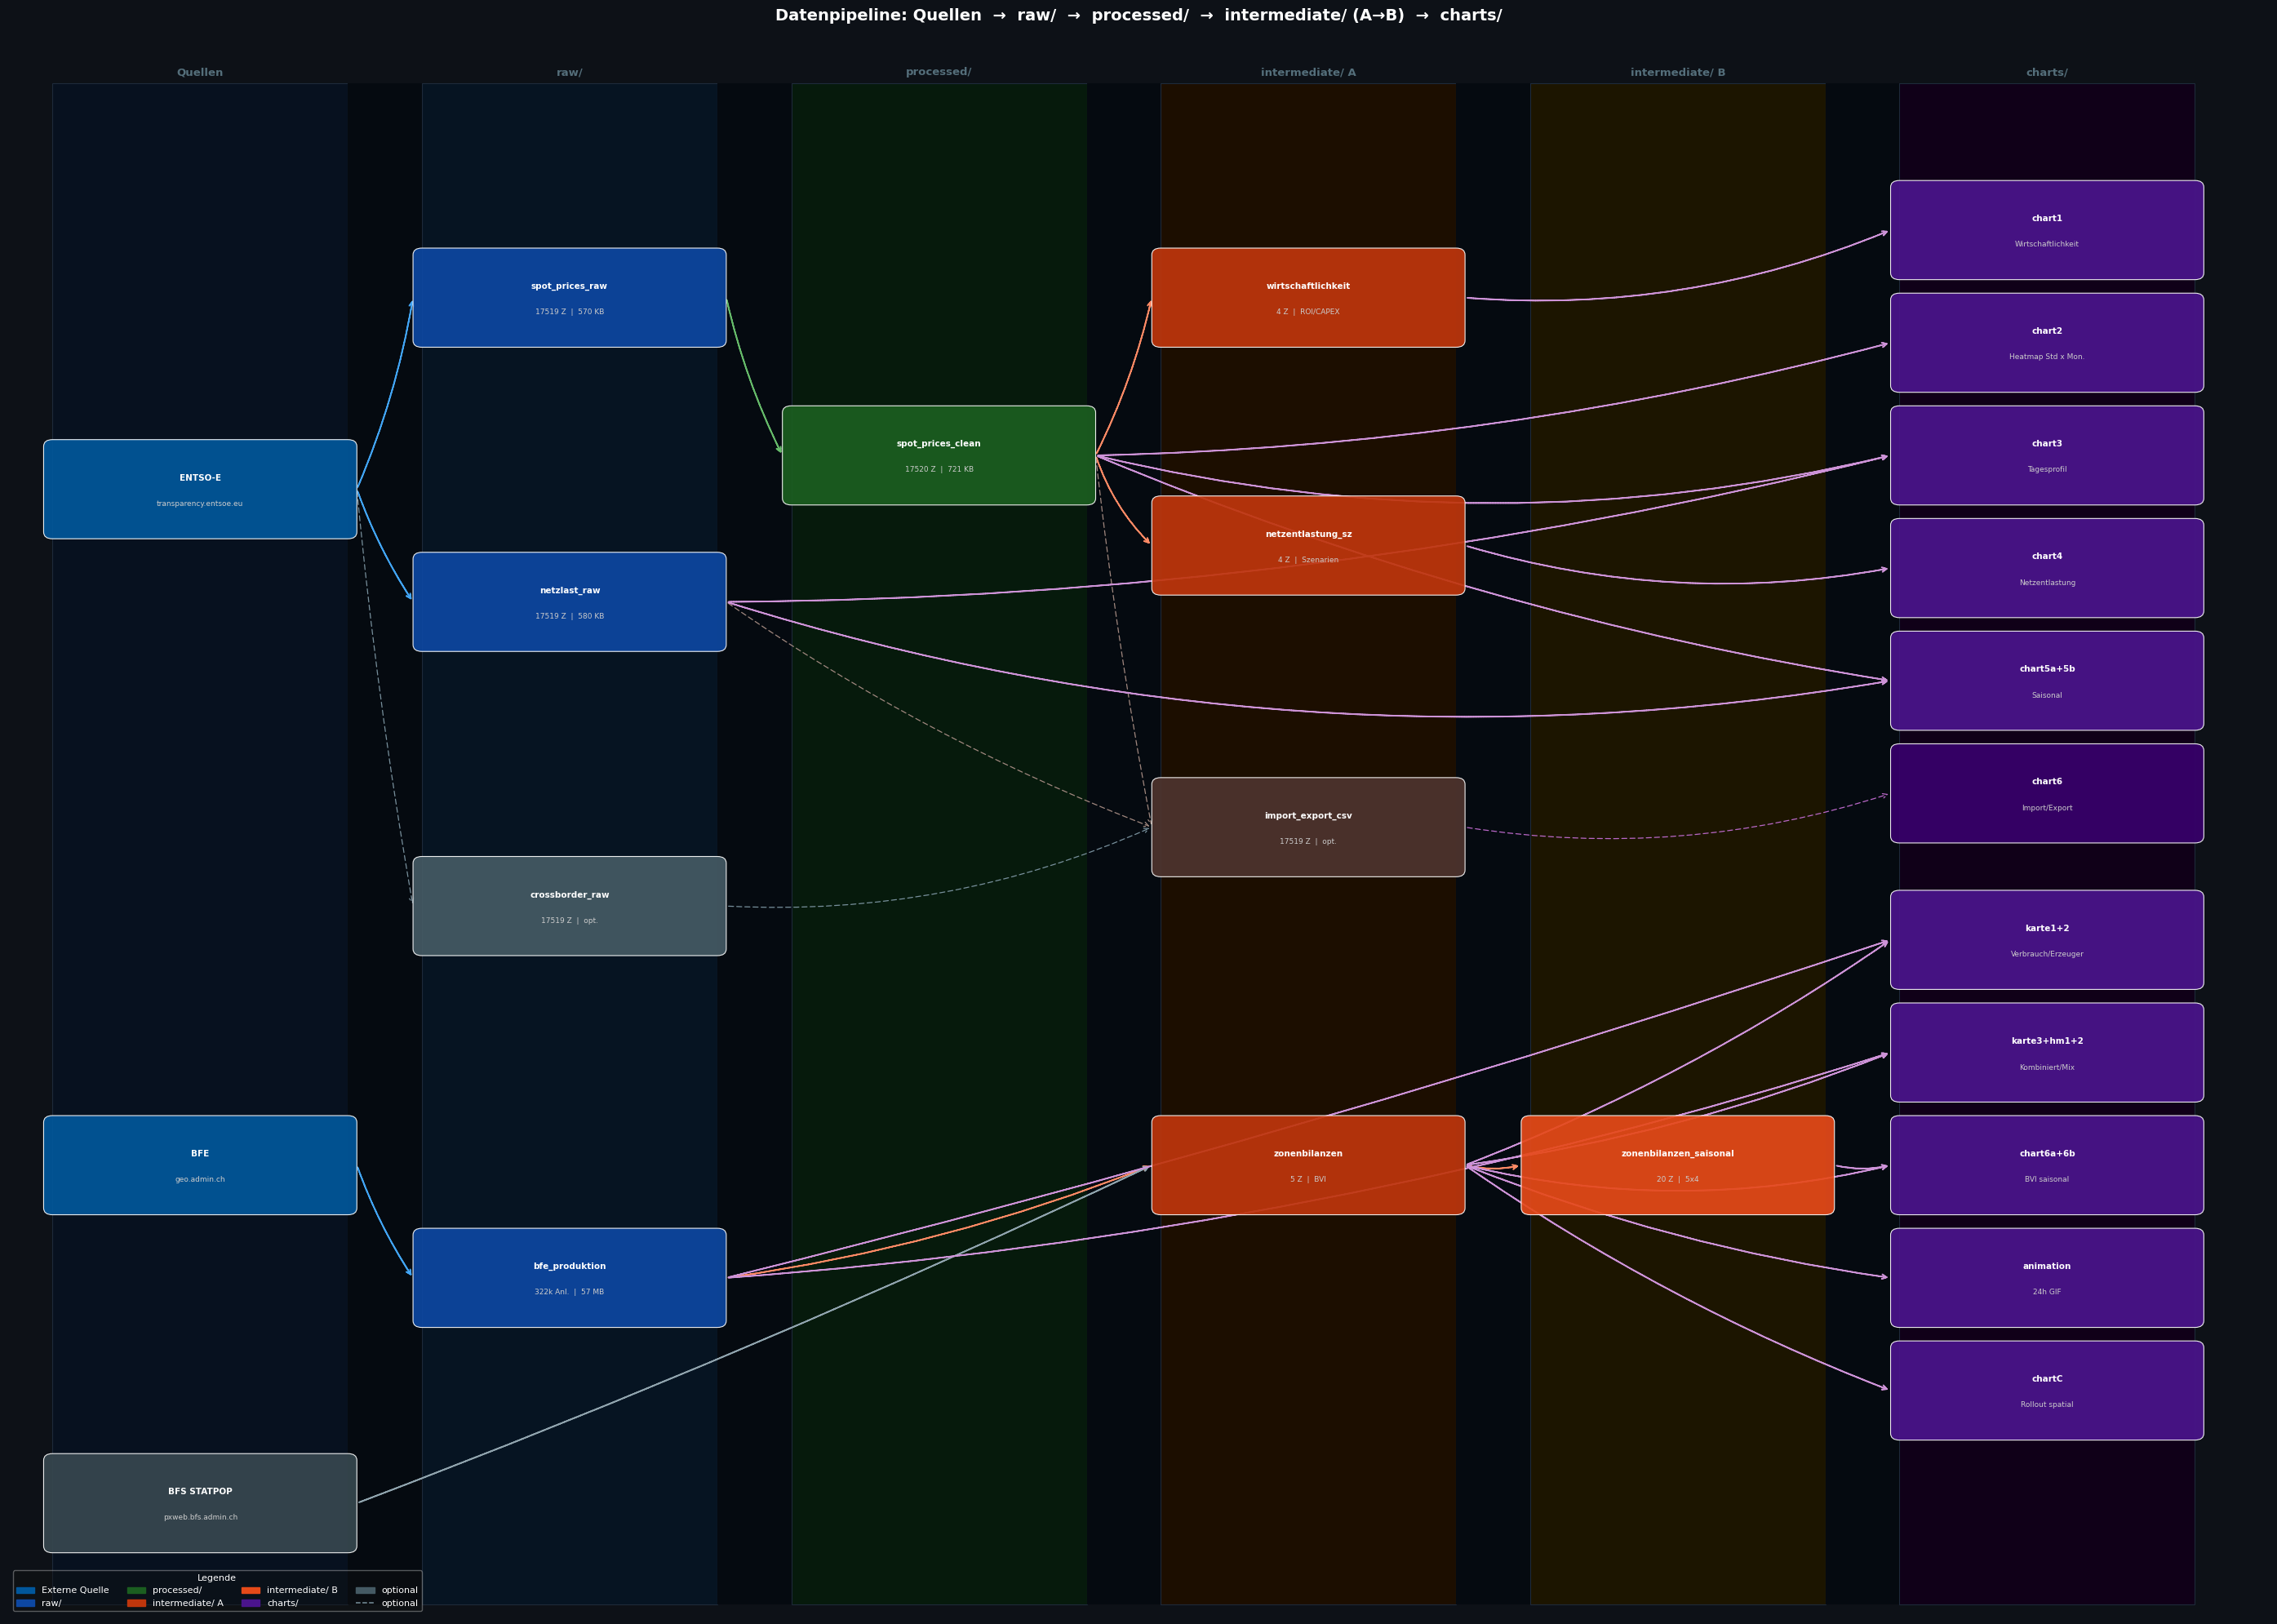

Chart C: output\charts\realistisch\nb99_prov_pipeline.png


In [6]:
# ── Chart C: Datenpipeline ───────────────────────────────────────────────────
from matplotlib.lines import Line2D

BW   = 1.00   # halbe Boxbreite
BH   = 0.38   # halbe Boxhoehe
SEP  = 0.50   # Trennspaltenbreite
CW   = 2.00   # Spaltenbreite (2×BW)

# Spalten-Mitten
XQ  =  1.0    # Quellen
XR  =  3.5    # raw/
XP  =  6.0    # processed/
XIA =  8.5    # intermediate/ A
XIB = 11.0    # intermediate/ B
XC  = 13.5    # charts/

NODES = [
    ('src_entsoe', XQ, 13.5, 'ENTSO-E',          'transparency.entsoe.eu',     '#01579B'),
    ('src_bfe',    XQ,  7.5, 'BFE',              'geo.admin.ch',               '#01579B'),
    ('src_bfs',    XQ,  4.5, 'BFS STATPOP',      'pxweb.bfs.admin.ch',         '#37474F'),
    ('raw_prices', XR, 15.2, 'spot_prices_raw',  '17519 Z  |  570 KB',         '#0D47A1'),
    ('raw_load',   XR, 12.5, 'netzlast_raw',     '17519 Z  |  580 KB',         '#0D47A1'),
    ('raw_cross',  XR,  9.8, 'crossborder_raw',  '17519 Z  |  opt.',           '#455A64'),
    ('raw_bfe',    XR,  6.5, 'bfe_produktion',   '322k Anl.  |  57 MB',        '#0D47A1'),
    ('proc_clean', XP, 13.8, 'spot_prices_clean', '17520 Z  |  721 KB',        '#1B5E20'),
    ('int_econ',   XIA, 15.2, 'wirtschaftlichkeit', '4 Z  |  ROI/CAPEX',       '#BF360C'),
    ('int_sz',     XIA, 13.0, 'netzentlastung_sz',  '4 Z  |  Szenarien',       '#BF360C'),
    ('int_ie',     XIA, 10.5, 'import_export_csv',  '17519 Z  |  opt.',        '#4E342E'),
    ('int_zb',     XIA,  7.5, 'zonenbilanzen',      '5 Z  |  BVI',             '#BF360C'),
    ('int_zbs',    XIB,  7.5, 'zonenbilanzen_saisonal', '20 Z  |  5x4',        '#E64A19'),
    ('ch1',  XC, 15.8, 'chart1',        'Wirtschaftlichkeit',   '#4A148C'),
    ('ch2',  XC, 14.8, 'chart2',        'Heatmap Std x Mon.',   '#4A148C'),
    ('ch3',  XC, 13.8, 'chart3',        'Tagesprofil',          '#4A148C'),
    ('ch4',  XC, 12.8, 'chart4',        'Netzentlastung',       '#4A148C'),
    ('ch5',  XC, 11.8, 'chart5a+5b',   'Saisonal',             '#4A148C'),
    ('ch6',  XC, 10.8, 'chart6',        'Import/Export',        '#38006B'),
    ('km12', XC,  9.5, 'karte1+2',     'Verbrauch/Erzeuger',   '#4A148C'),
    ('km3',  XC,  8.5, 'karte3+hm1+2', 'Kombiniert/Mix',       '#4A148C'),
    ('ch6b', XC,  7.5, 'chart6a+6b',   'BVI saisonal',         '#4A148C'),
    ('anim', XC,  6.5, 'animation',    '24h GIF',              '#4A148C'),
    ('chC',  XC,  5.5, 'chartC',       'Rollout spatial',      '#4A148C'),
]

EDGES = [
    ('src_entsoe','raw_prices','#42A5F5',False),
    ('src_entsoe','raw_load',  '#42A5F5',False),
    ('src_entsoe','raw_cross', '#78909C',True),
    ('src_bfe',   'raw_bfe',   '#42A5F5',False),
    ('raw_prices','proc_clean','#66BB6A',False),
    ('proc_clean','int_econ',  '#FF8A65',False),
    ('proc_clean','int_sz',    '#FF8A65',False),
    ('proc_clean','int_ie',    '#A1887F',True),
    ('raw_load',  'int_ie',    '#A1887F',True),
    ('raw_cross', 'int_ie',    '#78909C',True),
    ('raw_bfe',   'int_zb',    '#FF8A65',False),
    ('src_bfs',   'int_zb',    '#90A4AE',False),
    ('int_zb',    'int_zbs',   '#FF8A65',False),
    ('int_econ',  'ch1',  '#CE93D8',False),
    ('proc_clean','ch2',  '#CE93D8',False),
    ('proc_clean','ch3',  '#CE93D8',False),
    ('raw_load',  'ch3',  '#CE93D8',False),
    ('int_sz',    'ch4',  '#CE93D8',False),
    ('proc_clean','ch5',  '#CE93D8',False),
    ('raw_load',  'ch5',  '#CE93D8',False),
    ('int_ie',    'ch6',  '#BA68C8',True),
    ('raw_bfe',   'km12', '#CE93D8',False),
    ('int_zb',    'km12', '#CE93D8',False),
    ('raw_bfe',   'km3',  '#CE93D8',False),
    ('int_zb',    'km3',  '#CE93D8',False),
    ('int_zbs',   'ch6b', '#CE93D8',False),
    ('int_zb',    'ch6b', '#CE93D8',False),
    ('int_zb',    'anim', '#CE93D8',False),
    ('int_zb',    'chC',  '#CE93D8',False),
]

fig, ax = plt.subplots(figsize=(28, 20))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
YMAX = 17.5
ax.set_xlim(-0.3, 15.0)
ax.set_ylim(3.5, YMAX)
ax.axis('off')
ax.set_title(
    'Datenpipeline: Quellen  \u2192  raw/  \u2192  processed/'
    '  \u2192  intermediate/ (A\u2192B)  \u2192  charts/',
    color='white', fontsize=14, fontweight='bold', pad=16)

node_pos = {n[0]: (n[1], n[2]) for n in NODES}

# Spalten-Hintergrundbänder (Inhaltspalten)
BANDS = [
    ( 0.0,  2.0, 'Quellen',          '#07111f'),
    ( 2.5,  4.5, 'raw/',             '#061422'),
    ( 5.0,  7.0, 'processed/',       '#061a0c'),
    ( 7.5,  9.5, 'intermediate/ A',  '#1c0e00'),
    (10.0, 12.0, 'intermediate/ B',  '#1c1500'),
    (12.5, 14.5, 'charts/',          '#100018'),
]
# Trennspalten (zwischen je zwei Inhaltsspalten)
SEPS = [2.0, 4.5, 7.0, 9.5, 12.0]  # linke Kante jeder Trennspalte

for x0, x1, label, bg in BANDS:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x0, 3.6), x1-x0, YMAX-4.0,
        boxstyle='square,pad=0', facecolor=bg,
        edgecolor='#1e2a3a', linewidth=0.8, zorder=0))
    ax.text((x0+x1)/2, YMAX-0.3, label,
            ha='center', va='center', color='#546E7A',
            fontsize=9.5, fontweight='bold')

# Trennspalten: etwas dunkler
for sx in SEPS:
    ax.add_patch(mpatches.FancyBboxPatch(
        (sx, 3.6), SEP, YMAX-4.0,
        boxstyle='square,pad=0', facecolor='#050a10',
        edgecolor='none', linewidth=0, zorder=0))

# Kanten
for src_id, dst_id, col, opt in EDGES:
    x1v, y1v = node_pos[src_id]
    x2v, y2v = node_pos[dst_id]
    lw   = 0.9 if opt else 1.4
    dash = (5, 3) if opt else (1, 0)
    dy   = abs(y1v - y2v)
    rad  = 0.12 if dy < 1.0 else (0.06 if dy < 3.0 else 0.02)
    ax.annotate('',
        xy=(x2v - BW - 0.06, y2v),
        xytext=(x1v + BW + 0.06, y1v),
        arrowprops=dict(
            arrowstyle='->', color=col, lw=lw,
            linestyle=(0, dash),
            connectionstyle=f'arc3,rad={rad}'),
        zorder=1)

# Knoten
for nid, x, y, line1, line2, color in NODES:
    box = mpatches.FancyBboxPatch(
        (x-BW, y-BH), 2*BW, 2*BH,
        boxstyle='round,pad=0.06',
        facecolor=color, edgecolor='white',
        linewidth=0.8, alpha=0.92, zorder=2)
    ax.add_patch(box)
    ax.text(x, y + (0.10 if line2 else 0), line1,
            ha='center', va='center', color='white',
            fontsize=7.5, fontweight='bold', zorder=3)
    if line2:
        ax.text(x, y - 0.13, line2,
                ha='center', va='center', color='#cccccc',
                fontsize=6.5, zorder=3)

leg_items = [
    ('#01579B','Externe Quelle'),('#0D47A1','raw/'),
    ('#1B5E20','processed/'),    ('#BF360C','intermediate/ A'),
    ('#E64A19','intermediate/ B'),('#4A148C','charts/'),
    ('#455A64','optional'),
]
handles = [mpatches.Patch(color=c, label=l) for c,l in leg_items]
handles.append(Line2D([0],[0], color='#78909C', lw=1.1,
                      linestyle='--', label='optional'))
ax.legend(handles=handles, loc='lower left', fontsize=8,
          framealpha=0.4, facecolor='#111', labelcolor='white',
          title='Legende', title_fontsize=8, ncol=4)

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'nb99_prov_pipeline.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Chart C: {p}')


**Chart C — Pipeline-Flussdiagramm.** Zeigt den vollständigen Datenfluss von den
externen Quellen (ENTSO-E, BFE, BFS) bis zu den Visualisierungen. Die Dateigrössen
sind direkt aus dem dataindex annotiert. Dieses Diagramm aktualisiert sich automatisch
wenn neue Datensätze in den dataindex eingetragen werden.


---
## Chart D: Versionshistorie & Fehleranalyse


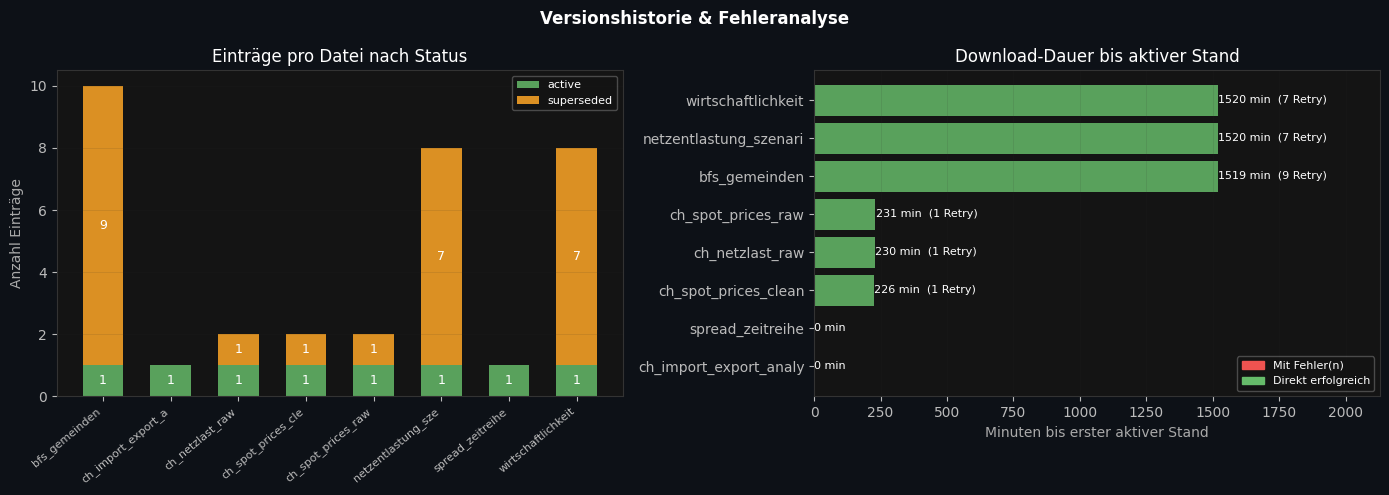

Chart D gespeichert: output\charts\realistisch\nb99_prov_versionshistorie.png


In [7]:
# ── Chart D: Status-Matrix + Retry-Analyse ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#141414')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    ax.tick_params(colors='#bbbbbb')
fig.suptitle('Versionshistorie & Fehleranalyse', color='white', fontsize=12, fontweight='bold')

# Panel 1: Status-Balken gestapelt pro Datei
status_counts = (df.groupby(['label','status'])
                   .size().unstack(fill_value=0)
                   .reindex(columns=['active','superseded','error','partial'], fill_value=0))
files_list = status_counts.index.tolist()
x = np.arange(len(files_list))
w = 0.6
bottom = np.zeros(len(files_list))
ax = axes[0]
for status in ['active','superseded','error','partial']:
    if status in status_counts.columns:
        vals = status_counts[status].values
        if vals.sum() > 0:
            bars = ax.bar(x, vals, w, bottom=bottom,
                          color=STATUS_COLORS.get(status,'#888'), alpha=0.85, label=status)
            for bar, val, bot in zip(bars, vals, bottom):
                if val > 0:
                    ax.text(bar.get_x()+bar.get_width()/2, bot+val/2,
                            str(int(val)), ha='center', va='center', color='white', fontsize=9)
            bottom += vals
ax.set_xticks(x)
ax.set_xticklabels([f[:18] for f in files_list], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Anzahl Einträge', color='#aaa')
ax.set_title('Einträge pro Datei nach Status', color='white')
ax.legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, axis='y', alpha=0.12)

# Panel 2: Zeitspanne zwischen erstem Versuch und aktivem Stand
ax = axes[1]
retry_data = []
for fname, grp in df.groupby('filename'):
    grp = grp.sort_values('timestamp')
    first_ts  = grp['timestamp'].iloc[0]
    active    = grp[grp['status']=='active']
    errors    = (grp['status']=='error').sum()
    retries   = (grp['status']=='superseded').sum()
    if not active.empty:
        active_ts = active['timestamp'].iloc[0]
        delta_min = (active_ts - first_ts).total_seconds() / 60
        retry_data.append({'label': fname.replace('.csv','').replace('.gpkg','')[:22],
                           'delta_min': delta_min, 'errors': errors, 'retries': retries})

df_retry = pd.DataFrame(retry_data).sort_values('delta_min')
if len(df_retry) > 0:
    bar_cols = ['#EF5350' if e > 0 else '#66BB6A' for e in df_retry['errors']]
    bars = ax.barh(df_retry['label'], df_retry['delta_min'], color=bar_cols, alpha=0.85)
    for bar, val, err, ret in zip(bars, df_retry['delta_min'],
                                   df_retry['errors'], df_retry['retries']):
        note = []
        if err > 0:  note.append(f'{err} Fehler')
        if ret > 0:  note.append(f'{ret} Retry')
        ax.text(bar.get_width() + 0.3, bar.get_y()+bar.get_height()/2,
                f'{val:.0f} min' + (f'  ({", ".join(note)})' if note else ''),
                va='center', color='white', fontsize=8)
    ax.set_xlabel('Minuten bis erster aktiver Stand', color='#aaa')
    ax.set_title('Download-Dauer bis aktiver Stand', color='white')
    ax.grid(True, axis='x', alpha=0.12)
    ax.set_xlim(0, df_retry['delta_min'].max() * 1.4 + 1)

    handles = [mpatches.Patch(color='#EF5350', label='Mit Fehler(n)'),
               mpatches.Patch(color='#66BB6A', label='Direkt erfolgreich')]
    ax.legend(handles=handles, fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'nb99_prov_versionshistorie.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Chart D gespeichert: {p}')


**Chart D — Versionshistorie.** Links: wie viele Einträge (active, superseded, error)
existieren pro Datei — zeigt welche Datensätze mehrfach heruntergeladen wurden.
Rechts: die Zeitspanne zwischen dem ersten Versuch und dem ersten aktiven Stand.
Rote Balken markieren Dateien die vorher mindestens einmal fehlgeschlagen sind —
ein direktes Mass für die API-Zuverlässigkeit.


---
## Zusammenfassung


In [8]:
# ── Zusammenfassung ──────────────────────────────────────────────────────────
print('=' * 60)
print('DATAINDEX ZUSAMMENFASSUNG')
print('=' * 60)
print(f'  Gesamt-Einträge   : {len(df)}')
print(f'  Aktive Datensätze : {len(df_active)}')
print(f'  Fehler            : {(df["status"]=="error").sum()} '
      f'({(df["status"]=="error").mean()*100:.0f}% aller Versuche)')
total_active_mb = df_active["size_kb"].sum() / 1024
print(f'  Gesamt Datengrösse: {total_active_mb:.1f} MB (aktive Datensätze)')

print()
print('  Pipeline-Verteilung (aktive Einträge):')
for dt, grp in df_active.groupby('data_type'):
    pct = len(grp)/len(df_active)*100
    bar = '█' * int(pct/5)
    print(f'  {TYPE_LABELS.get(dt,dt):<35} {bar} {len(grp)} Datei(en)')

print()
print('  Charts gespeichert unter charts/:')
for f in sorted(os.listdir(CHARTS_DIR)):
    if f.startswith('prov_'):
        kb = os.path.getsize(os.path.join(CHARTS_DIR, f))/1024
        print(f'  ✅ {f:<40} {kb:.0f} KB')

print()
print('NB6 abgeschlossen.')


DATAINDEX ZUSAMMENFASSUNG
  Gesamt-Einträge   : 34
  Aktive Datensätze : 8
  Fehler            : 0 (0% aller Versuche)
  Gesamt Datengrösse: 2.4 MB (aktive Datensätze)

  Pipeline-Verteilung (aktive Einträge):
  Zwischenergebnisse (intermediate/)  ██████████ 4 Datei(en)
  intermediate/realistisch            ██ 1 Datei(en)
  processed/sim                       ██ 1 Datei(en)
  Simuliert (sim/raw/)                █████ 2 Datei(en)

  Charts gespeichert unter charts/:

NB6 abgeschlossen.


**Zusammenfassung.** Alle vier Charts zeigen komplementäre Perspektiven auf denselben
dataindex. Das Notebook ist wartungsfrei: sobald NB1 oder NB2 neue Einträge schreiben,
werden alle Charts automatisch aktualisiert — ohne eine einzige Zeile Code zu ändern.


---
[↑ Projektübersicht](00_Project_Overview.ipynb)
